成功加载数据，关联函数长度: 5001


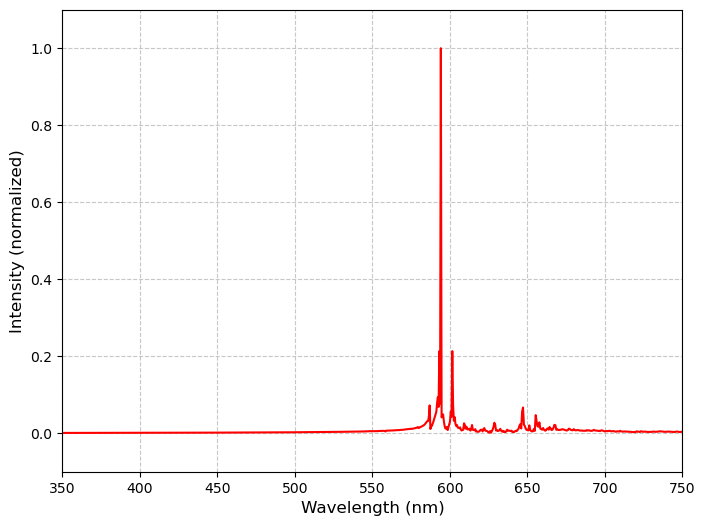

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from renormalizer.utils import constant
# ================= 配置参数 (需与 run_monomer.py 一致) =================
           
# ======================================================================
def autocorr_to_spectrum(
    path="../singleset/pbi_dimer_ft_chi42.npz",
    t_gaussian_fs=None,
    offset_ev=2.13,
    spectratype="abs",
    apply_prefactor=False,
    xlim_nm=(350, 750),
):
    try:
        data = np.load(path)
        print(f"成功加载数据，关联函数长度: {len(data['autocorr'])}")
    except:
        print("错误：未找到 autocorr_data.npy 文件！")
        return

    times_au = data["time_series"]
    dt_au = times_au[1] - times_au[0]

    autocorr = np.asarray(data["autocorr"])
    t_axis = times_au - times_au[0]
    
    if t_gaussian_fs is None:
        broadening_filter = np.ones_like(t_axis, dtype=float)
    else:
        t_gaussian_au = t_gaussian_fs * constant.fs2au
        broadening_filter = np.exp(-(t_axis / t_gaussian_au)**2)
    c_t_broadened = autocorr * broadening_filter

    # 与已验证的零温后处理保持一致：正时间关联函数直接 FFT。
    spectrum = np.fft.fft(c_t_broadened)
    relative_freqs_au = -np.fft.fftfreq(len(autocorr), d=dt_au) * 2 * np.pi
    
    # Add the electronic transition offset back to the relative FFT frequency.
    freqs_au = relative_freqs_au + offset_ev * constant.ev2au
    freqs_cm = freqs_au * constant.au2cm
    
    intensities = np.abs(spectrum)
    if apply_prefactor:
        if spectratype == "abs":
            intensities *= freqs_au
        elif spectratype == "emi":
            intensities *= freqs_au**3
        else:
            raise ValueError("spectratype should be 'abs' or 'emi'")

    # 数据筛选：波数转波长，lambda(nm) = 1e7 / wavenumber(cm^-1)
    positive_freq = freqs_cm > 0
    wavelength_nm = 1e7 / freqs_cm[positive_freq]
    intensities = intensities[positive_freq]
    plot_window = (wavelength_nm >= xlim_nm[0]) & (wavelength_nm <= xlim_nm[1])
    max_intensity = np.max(intensities[plot_window])
    if max_intensity != 0:
        intensities = intensities / max_intensity

    # 排序以方便画图
    idx = np.argsort(wavelength_nm)
    x = wavelength_nm[idx]
    y = intensities[idx]

    plt.figure(figsize=(8, 6))

    plt.xlim(*xlim_nm)
    plt.ylim(-0.1,1.1)
    plt.plot(x, y, color='red', linewidth=1.5)

    plt.xlabel("Wavelength (nm)", fontsize=12)
    plt.ylabel("Intensity (normalized)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # 保存结果
    # plt.savefig(f"dimer_spectrum.png", dpi=300)
    plt.show()

if __name__ == "__main__":
    autocorr_to_spectrum(
        path="../multiset/pbi_dimer_ft_emi_multiset.npz",
        offset_ev=2.13 - 0.086,
        spectratype="emi",
        apply_prefactor=False,
    )
    # "../multiset/pbi_dimer.npz"

成功加载数据: ../singleset/pbi_dimer_ft_abs_42bd.npz, 关联函数长度: 5001
成功加载数据: ../singleset/pbi_dimer_ft_emi_42bd.npz, 关联函数长度: 5001


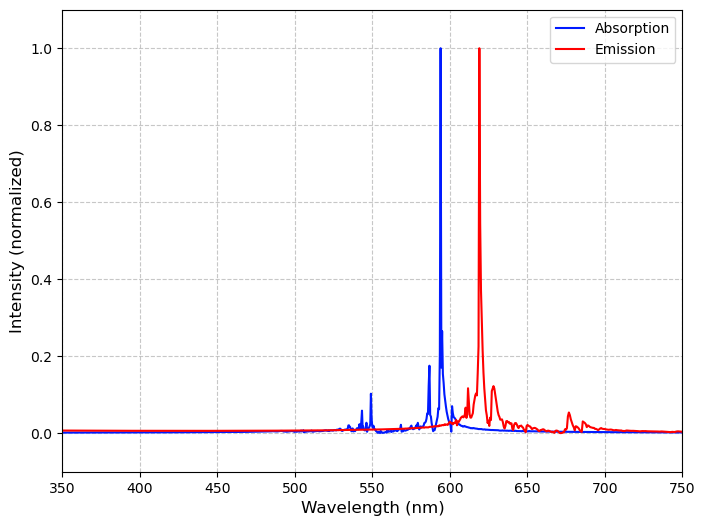

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from renormalizer.utils import constant

def autocorr_to_spectrum(
    path,
    t_gaussian_fs=None,
    offset_ev=2.13,
    spectratype="abs",
    apply_prefactor=False,
    xlim_nm=(350, 750),
):
    data = np.load(path)
    print(f"成功加载数据: {path}, 关联函数长度: {len(data['autocorr'])}")

    times_au = data["time_series"]
    dt_au = times_au[1] - times_au[0]
    autocorr = np.asarray(data["autocorr"])
    t_axis = times_au - times_au[0]

    if t_gaussian_fs is None:
        broadening_filter = np.ones_like(t_axis, dtype=float)
    else:
        t_gaussian_au = t_gaussian_fs * constant.fs2au
        broadening_filter = np.exp(-(t_axis / t_gaussian_au) ** 2)
    c_t_broadened = autocorr * broadening_filter

    spectrum = np.fft.fft(c_t_broadened)
    fft_freqs_au = np.fft.fftfreq(len(autocorr), d=dt_au) * 2 * np.pi
    offset_au = offset_ev * constant.ev2au

    # 对同一份正时间关联函数，吸收和发射在频率轴上的映射方向相反。
    # 这样发射谱的振动峰列会落在与论文 Figure 4 一致的一侧，而不是左右镜像翻转。
    if spectratype == "abs":
        freqs_au = offset_au - fft_freqs_au
    elif spectratype == "emi":
        freqs_au = offset_au + fft_freqs_au
    else:
        raise ValueError("spectratype should be 'abs' or 'emi'")
    freqs_cm = freqs_au * constant.au2cm

    intensities = np.abs(spectrum)
    if apply_prefactor:
        if spectratype == "abs":
            intensities *= freqs_au
        elif spectratype == "emi":
            intensities *= freqs_au ** 3
        else:
            raise ValueError("spectratype should be 'abs' or 'emi'")

    positive_freq = freqs_cm > 0
    wavelength_nm = 1e7 / freqs_cm[positive_freq]
    intensities = intensities[positive_freq]

    idx = np.argsort(wavelength_nm)
    x = wavelength_nm[idx]
    y = intensities[idx]

    plot_window = (x >= xlim_nm[0]) & (x <= xlim_nm[1])
    max_intensity = np.max(y[plot_window])
    if max_intensity != 0:
        y = y / max_intensity

    return x, y

if __name__ == "__main__":
    xlim_nm = (350, 750)
    abs_x, abs_y = autocorr_to_spectrum(
        path="../singleset/pbi_dimer_ft_abs_42bd.npz",
        offset_ev=2.13,
        spectratype="abs",
        apply_prefactor=True,
        xlim_nm=xlim_nm,
    )
    emi_x, emi_y = autocorr_to_spectrum(
        path="../singleset/pbi_dimer_ft_emi_42bd.npz",
        offset_ev=2.13 - 0.086,
        spectratype="emi",
        apply_prefactor=True,
        xlim_nm=xlim_nm,
    )

    plt.figure(figsize=(8, 6))
    plt.plot(abs_x, abs_y, color="#001AFF", linewidth=1.5, label="Absorption")
    plt.plot(emi_x, emi_y, color="#FF0000", linewidth=1.5, label="Emission")
    plt.xlim(*xlim_nm)
    plt.ylim(-0.1, 1.1)
    plt.xlabel("Wavelength (nm)", fontsize=12)
    plt.ylabel("Intensity (normalized)", fontsize=12)
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.legend()
    plt.show()
